In [1]:
!pip install open3d

You should consider upgrading via the '/opt/conda/bin/python -m pip install --upgrade pip' command.


In [2]:
import open3d as o3d
import numpy as np
import os
from scipy.stats import special_ortho_group

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
import copy
def draw_registration_result(source, target, transformation):
    source_temp = copy.deepcopy(source)
    target_temp = copy.deepcopy(target)
    # source_temp.paint_uniform_color([1, 0.706, 0])
    # target_temp.paint_uniform_color([0, 0.651, 0.929])
    source_temp.transform(transformation)
    o3d.visualization.draw_geometries([source_temp, target_temp],
                                      zoom=0.4459,
                                      front=[0.9288, -0.2951, -0.2242],
                                      lookat=[1.6784, 2.0612, 1.4451],
                                      up=[-0.3402, -0.9189, -0.1996])

In [4]:
pcd_dir = "output_pcds"
point_cloud_files = sorted(os.listdir(pcd_dir))  # Sort files to maintain order
point_cloud_files = [os.path.join(pcd_dir, f) for f in point_cloud_files][:10]


In [5]:
# Function to register two point clouds using ICP
def icp_registration(pcd1, pcd2, threshold=0.6, initial_guess=np.eye(4), max_iterations=2000):
    reg_p2p = o3d.pipelines.registration.registration_icp(
        pcd1, pcd2, threshold, initial_guess,
        o3d.pipelines.registration.TransformationEstimationPointToPoint(),
        o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=max_iterations)
    )
    return reg_p2p.transformation

In [6]:
# point_clouds = [o3d.io.read_point_cloud(f) for f in point_cloud_files]

point_clouds = point_cloud_files
# Initialize global transformation list
global_transformations = [np.eye(4)]  # Identity for the first cloud
# global_transformations = [[[-1.77804560e-01, -9.84064725e-01,  1.46799224e-03, -7.99785952e-02],
#                             [ 9.84065463e-01, -1.77805569e-01, -5.86609758e-04,  5.89522761e-02],
#                             [ 8.38279166e-04,  1.34029858e-03,  9.99998750e-01, -7.47250756e-03],
#                             [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00]]]


# Register point clouds sequentially
for i in range(1, len(point_clouds)):
    print(f"Registering point cloud {i} to {i-1}")

    pcd1 = point_clouds[i - 1]
    pcd2 = point_clouds[i]

    # Compute transformation using ICP
    transformation = icp_registration(pcd2, pcd1)

    # Update global transformation
    global_transformations.append(global_transformations[i - 1] @ transformation)

# Apply transformations to align all point clouds
aligned_pcds = []
for i, pcd in enumerate(point_clouds):
    pcd.transform(global_transformations[i])
    aligned_pcds.append(pcd)

# Merge all aligned point clouds into one
merged_pcd = aligned_pcds[0]
for i in range(1, len(aligned_pcds)):
    merged_pcd += aligned_pcds[i]

# Save and visualize the final merged point cloud
# o3d.io.write_point_cloud("merged_output.pcd", merged_pcd)


Registering point cloud 1 to 0


TypeError: registration_icp(): incompatible function arguments. The following argument types are supported:
    1. (source: open3d.cpu.pybind.geometry.PointCloud, target: open3d.cpu.pybind.geometry.PointCloud, max_correspondence_distance: float, init: numpy.ndarray[numpy.float64[4, 4]] = array([[1., 0., 0., 0.], [0., 1., 0., 0.], [0., 0., 1., 0.], [0., 0., 0., 1.]]), estimation_method: open3d.cpu.pybind.pipelines.registration.TransformationEstimation = TransformationEstimationPointToPoint(with_scaling=False), criteria: open3d.cpu.pybind.pipelines.registration.ICPConvergenceCriteria = ICPConvergenceCriteria(relative_fitness=1.000000e-06, relative_rmse=1.000000e-06, max_iteration=30)) -> open3d.cpu.pybind.pipelines.registration.RegistrationResult

Invoked with: 'output_pcds/pointcloud_0001.pcd', 'output_pcds/pointcloud_0000.pcd', 0.6, array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]]), TransformationEstimationPointToPoint(with_scaling=Fal

In [18]:
o3d.visualization.draw_geometries([merged_pcd])

error: XDG_RUNTIME_DIR not set in the environment.


Registering point cloud 1 to 0
Registering point cloud 2 to 1
Registering point cloud 3 to 2
Registering point cloud 4 to 3
Registering point cloud 5 to 4
Registering point cloud 6 to 5
Registering point cloud 7 to 6
Registering point cloud 8 to 7
Registering point cloud 9 to 8
Registering point cloud 10 to 9
Registering point cloud 11 to 10
Registering point cloud 12 to 11
Registering point cloud 13 to 12
Registering point cloud 14 to 13
Registering point cloud 15 to 14
Registering point cloud 16 to 15
Registering point cloud 17 to 16
Registering point cloud 18 to 17
Registering point cloud 19 to 18
Registering point cloud 20 to 19
Registering point cloud 21 to 20
Registering point cloud 22 to 21
Registering point cloud 23 to 22
Registering point cloud 24 to 23
Registering point cloud 25 to 24
Registering point cloud 26 to 25
Registering point cloud 27 to 26
Registering point cloud 28 to 27
Registering point cloud 29 to 28
Registering point cloud 30 to 29
Registering point cloud 31 to

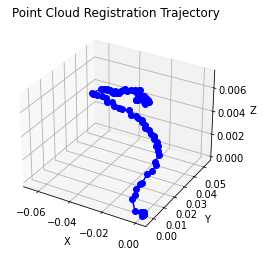

error: XDG_RUNTIME_DIR not set in the environment.


In [20]:
import os
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

# Function to register two point clouds using ICP
def icp_registration(pcd1, pcd2, threshold=0.6, initial_guess=np.eye(4), max_iterations=2000):
    reg_p2p = o3d.pipelines.registration.registration_icp(
        pcd1, pcd2, threshold, initial_guess,
        o3d.pipelines.registration.TransformationEstimationPointToPoint(),
        o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=max_iterations)
    )
    return reg_p2p.transformation

pcd_dir = "output_pcds"
point_cloud_files = sorted(os.listdir(pcd_dir))  # Sort files to maintain order
point_cloud_files = [os.path.join(pcd_dir, f) for f in point_cloud_files][:400:4]

# Read point clouds
point_clouds = [o3d.io.read_point_cloud(f) for f in point_cloud_files]

# Initialize global transformation list
global_transformations = [np.eye(4)]  # Identity for the first cloud

# Store trajectory points
trajectory_points = [np.array([0, 0, 0])]  # Origin for the first cloud

# Register point clouds sequentially
for i in range(1, len(point_clouds)):
    print(f"Registering point cloud {i} to {i-1}")

    pcd1 = point_clouds[i - 1]
    pcd2 = point_clouds[i]

    # Compute transformation using ICP
    transformation = icp_registration(pcd2, pcd1)

    # Update global transformation
    global_transformations.append(global_transformations[i - 1] @ transformation)

    # Extract translation (x, y, z) and store in trajectory
    trajectory_points.append(global_transformations[i][:3, 3])

# Convert trajectory points to NumPy array
trajectory_points = np.array(trajectory_points)

# Plot the trajectory
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(trajectory_points[:, 0], trajectory_points[:, 1], trajectory_points[:, 2], marker='o', linestyle='-', color='b')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Point Cloud Registration Trajectory')

plt.show()

# Apply transformations to align all point clouds
aligned_pcds = []
for i, pcd in enumerate(point_clouds):
    pcd.transform(global_transformations[i])
    aligned_pcds.append(pcd)

# Merge all aligned point clouds into one
merged_pcd = aligned_pcds[0]
for i in range(1, len(aligned_pcds)):
    merged_pcd += aligned_pcds[i]

# Save and visualize the final merged point cloud
o3d.io.write_point_cloud("merged_output.pcd", merged_pcd)
o3d.visualization.draw_geometries([merged_pcd])


In [22]:
import os
import shutil

# Define source and destination folders
source_dir = "output_pcds"
destination_dir = "selected_pcds"

# Ensure the destination directory exists
os.makedirs(destination_dir, exist_ok=True)

# List and select every 4th file up to 400
point_cloud_files = sorted(os.listdir(source_dir))[:400:4]
selected_files = [os.path.join(source_dir, f) for f in point_cloud_files]

# Copy selected files to the new directory
for file in selected_files:
    shutil.copy(file, destination_dir)

Registering point cloud 1 to 0
Registering point cloud 2 to 1
Registering point cloud 3 to 2
Registering point cloud 4 to 3
Registering point cloud 5 to 4
Registering point cloud 6 to 5
Registering point cloud 7 to 6
Registering point cloud 8 to 7
Registering point cloud 9 to 8
Registering point cloud 10 to 9
Registering point cloud 11 to 10
Registering point cloud 12 to 11
Registering point cloud 13 to 12
Registering point cloud 14 to 13
Registering point cloud 15 to 14
Registering point cloud 16 to 15
Registering point cloud 17 to 16
Registering point cloud 18 to 17
Registering point cloud 19 to 18
Registering point cloud 20 to 19
Registering point cloud 21 to 20
Registering point cloud 22 to 21
Registering point cloud 23 to 22
Registering point cloud 24 to 23
Registering point cloud 25 to 24
Registering point cloud 26 to 25
Registering point cloud 27 to 26
Registering point cloud 28 to 27
Registering point cloud 29 to 28
Registering point cloud 30 to 29
Registering point cloud 31 to

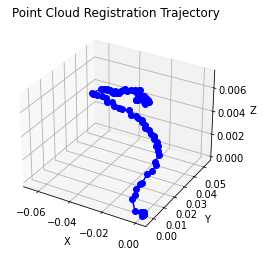

error: XDG_RUNTIME_DIR not set in the environment.


In [23]:
import os
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

# Function to register two point clouds using ICP
def icp_registration(pcd1, pcd2, threshold=0.6, initial_guess=np.eye(4), max_iterations=2000):
    reg_p2p = o3d.pipelines.registration.registration_icp(
        pcd1, pcd2, threshold, initial_guess,
        o3d.pipelines.registration.TransformationEstimationPointToPoint(),
        o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=max_iterations)
    )
    return reg_p2p.transformation

pcd_dir = "selected_pcds"
point_cloud_files = sorted(os.listdir(pcd_dir))  # Sort files to maintain order
point_cloud_files = [os.path.join(pcd_dir, f) for f in point_cloud_files]

# Read point clouds
point_clouds = [o3d.io.read_point_cloud(f) for f in point_cloud_files]

# Initialize global transformation list
global_transformations = [np.eye(4)]  # Identity for the first cloud

# Store trajectory points
trajectory_points = [np.array([0, 0, 0])]  # Origin for the first cloud

# Register point clouds sequentially
for i in range(1, len(point_clouds)):
    print(f"Registering point cloud {i} to {i-1}")

    pcd1 = point_clouds[i - 1]
    pcd2 = point_clouds[i]

    # Compute transformation using ICP
    transformation = icp_registration(pcd2, pcd1)

    # Update global transformation
    global_transformations.append(global_transformations[i - 1] @ transformation)

    # Extract translation (x, y, z) and store in trajectory
    trajectory_points.append(global_transformations[i][:3, 3])

# Convert trajectory points to NumPy array
trajectory_points = np.array(trajectory_points)

# Plot the trajectory
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(trajectory_points[:, 0], trajectory_points[:, 1], trajectory_points[:, 2], marker='o', linestyle='-', color='b')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Point Cloud Registration Trajectory')

plt.show()

# Apply transformations to align all point clouds
aligned_pcds = []
for i, pcd in enumerate(point_clouds):
    pcd.transform(global_transformations[i])
    aligned_pcds.append(pcd)

# Merge all aligned point clouds into one
merged_pcd = aligned_pcds[0]
for i in range(1, len(aligned_pcds)):
    merged_pcd += aligned_pcds[i]

# Save and visualize the final merged point cloud
# o3d.io.write_point_cloud("merged_output.pcd", merged_pcd)
o3d.visualization.draw_geometries([merged_pcd])
